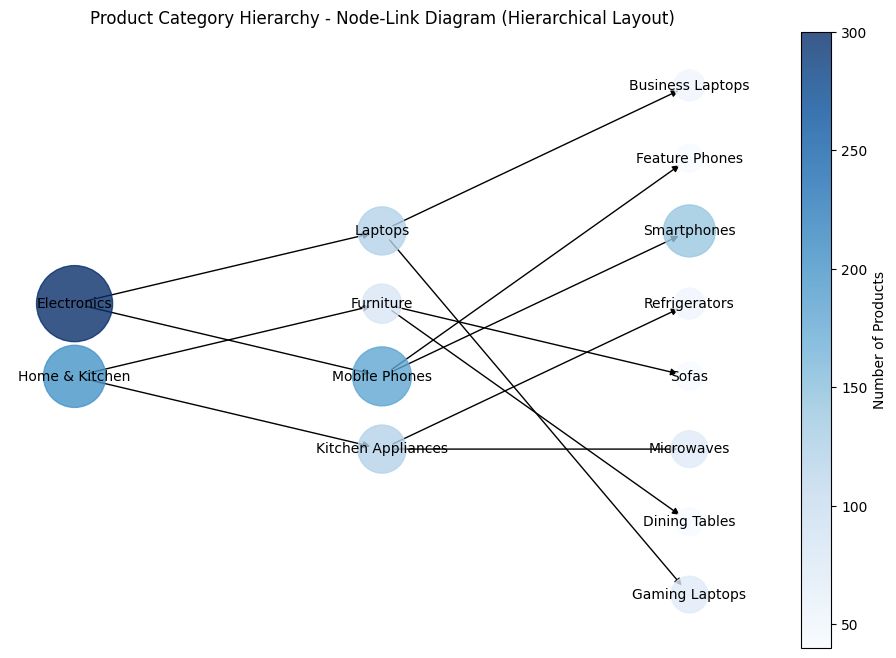

In [5]:
#1. Node-Link Diagram (Tree)
import matplotlib.pyplot as plt
import networkx as nx

edges = [
    ("Electronics", "Mobile Phones"),
    ("Electronics", "Laptops"),
    ("Mobile Phones", "Smartphones"),
    ("Mobile Phones", "Feature Phones"),
    ("Laptops", "Gaming Laptops"),
    ("Laptops", "Business Laptops"),
    ("Home & Kitchen", "Kitchen Appliances"),
    ("Home & Kitchen", "Furniture"),
    ("Kitchen Appliances", "Microwaves"),
    ("Kitchen Appliances", "Refrigerators"),
    ("Furniture", "Sofas"),
    ("Furniture", "Dining Tables"),
]

node_counts = {
    "Electronics": 300,
    "Mobile Phones": 180,
    "Smartphones": 140,
    "Feature Phones": 40,
    "Laptops": 120,
    "Gaming Laptops": 70,
    "Business Laptops": 50,
    "Home & Kitchen": 200,
    "Kitchen Appliances": 120,
    "Microwaves": 70,
    "Refrigerators": 50,
    "Furniture": 80,
    "Sofas": 40,
    "Dining Tables": 40,
}

G = nx.DiGraph()
G.add_edges_from(edges)

def get_depths(G, root):
    depths = {root: 0}
    queue = [root]
    while queue:
        node = queue.pop(0)
        for child in G.successors(node):
            depths[child] = depths[node] + 1
            queue.append(child)
    return depths

roots = [n for n in G.nodes if G.in_degree(n) == 0]
depths = {}
for root in roots:
    depths.update(get_depths(G, root))

layers = {}
for node, depth in depths.items():
    layers.setdefault(depth, []).append(node)

# Assign depth as node attribute 'layer'
for depth, nodes_in_layer in layers.items():
    for n in nodes_in_layer:
        G.nodes[n]['layer'] = depth

pos = nx.multipartite_layout(G, subset_key='layer')

sizes = [node_counts[node] * 10 for node in G.nodes()]
colors = [node_counts[node] for node in G.nodes()]

plt.figure(figsize=(12, 8))
nodes = nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap=plt.cm.Blues, alpha=0.8)
nx.draw_networkx_edges(G, pos, arrows=True)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Product Category Hierarchy - Node-Link Diagram (Hierarchical Layout)")
plt.colorbar(nodes, label='Number of Products')
plt.axis('off')
plt.show()



In [8]:
#2. Indented Tree (AST Visualization)
# Expression: (1 + 2) - 3 * (7 / 4 + (5 - 7))

# Define the AST as nested tuples (Operator, Left subtree, Right subtree) or leaf nodes
ast = (
    '-', 
    ('+', 1, 2),
    ('*', 3, ('+', ('/', 7, 4), ('-', 5, 7)))
)

def print_indented_tree(node, indent=""):
    if isinstance(node, tuple):
        op, left, right = node
        print(indent + op)
        print_indented_tree(left, indent + "├── ")
        print_indented_tree(right, indent + "└── ")
    else:
        print(indent + str(node))

print_indented_tree(ast)


-
├── +
├── ├── 1
├── └── 2
└── *
└── ├── 3
└── └── +
└── └── ├── /
└── └── ├── ├── 7
└── └── ├── └── 4
└── └── └── -
└── └── └── ├── 5
└── └── └── └── 7


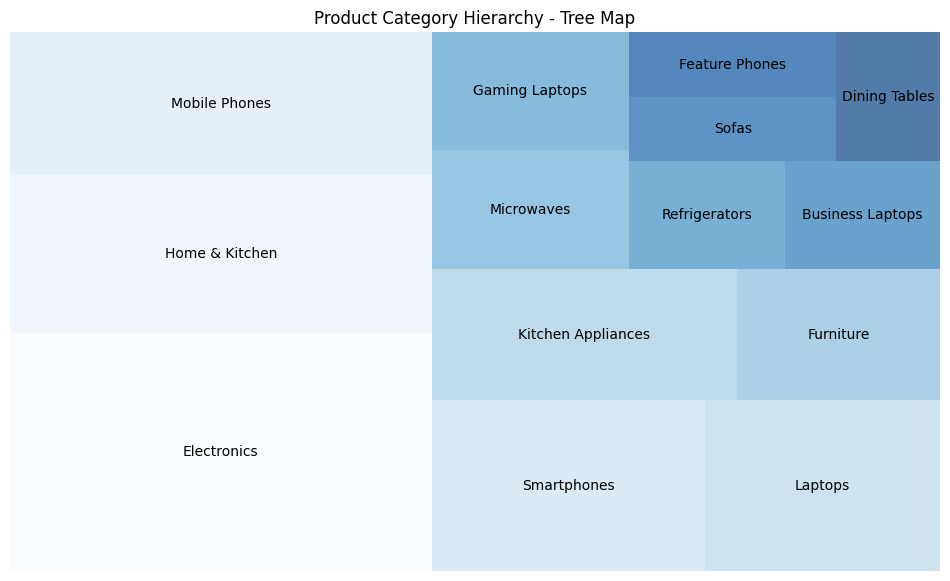

In [11]:
#3. Tree Map
import squarify
import matplotlib.pyplot as plt

# Using same data from Node-Link diagram (node_counts)
labels = list(node_counts.keys())
sizes = list(node_counts.values())

# Sort sizes and labels descending
sizes_sorted, labels_sorted = zip(*sorted(zip(sizes, labels), reverse=True))

# Generate colors for each block
colors = [plt.cm.Blues(i / len(sizes_sorted)) for i in range(len(sizes_sorted))]

plt.figure(figsize=(12, 7))
squarify.plot(sizes=sizes_sorted, label=labels_sorted, alpha=0.7, color=colors)
plt.title('Product Category Hierarchy - Tree Map')
plt.axis('off')
plt.show()
